In [1]:
!pip install geemap earthengine-api matplotlib numpy --quiet
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.3 MB/s eta 0:00:00
Done!


In [2]:
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt

ee.Authenticate(auth_mode='notebook')

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=WvaOMGHYVO8ohBXCQCEWpxSl_n7S1rNGUV9LLbxHSWg&tc=gnAOy7RJ7kMDhaBaHwNQBXJ798_fY3MOvlSVmRANYV8&cc=adVJQvevcpfpYOwn0mJl0V1m7OwbMw29U3MnwjkCe2I

The authorization workflow will generate a code, which you should paste in the box below.
Enter verification code: 4/1Aci98E_2EihhDiWc74RsOutDiCp2bz0HClTlSFm5e3gARhRxOKqcwLmbcX8

Successfully saved authorization token.


In [3]:
ee.Initialize(project='project-911-491616')

# Same as Week 2 — load Savar images
savar = ee.Geometry.Rectangle([90.15, 23.75, 90.40, 24.00])

collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2023-11-01', '2024-02-28')
    .filterBounds(savar)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

image = collection.median().clip(savar)
print("Data loaded! Images found:", collection.size().getInfo())

Data loaded! Images found: 16


In [4]:
# B8 = NIR (Near Infrared), B4 = Red
# .normalizedDifference handles the formula safely — no divide by zero!
ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

print("NDVI computed successfully!")
print("Formula used: (B8 - B4) / (B8 + B4)")

NDVI computed successfully!
Formula used: (B8 - B4) / (B8 + B4)


In [5]:
Map = geemap.Map()
Map.centerObject(savar, 12)

# Colour palette: red=stressed, yellow=okay, green=healthy
ndvi_params = {
    'min': -0.2,
    'max': 0.8,
    'palette': ['red', 'yellow', 'lightgreen', 'darkgreen']
}

Map.addLayer(ndvi, ndvi_params, 'NDVI Health Map')
Map.addLayerControl()
Map

Map(center=[23.87501023032979, 90.27500000000053], controls=(WidgetControl(options=['position', 'transparent_b…

Sampled 500 pixels
Min NDVI:     -0.12
Max NDVI:     0.72
Average NDVI: 0.46


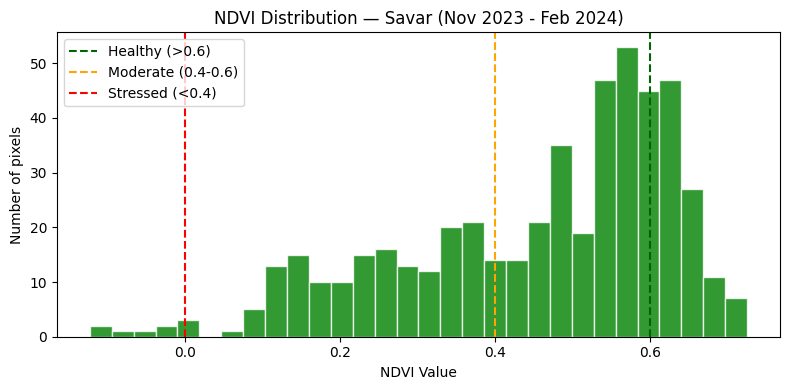

In [7]:
# Sample NDVI values from the image
ndvi_sample = ndvi.sample(
    region=savar,
    scale=100,
    numPixels=500
)

# Convert to list
values = ndvi_sample.aggregate_array('NDVI').getInfo()
print(f"Sampled {len(values)} pixels")
print(f"Min NDVI:     {min(values):.2f}")
print(f"Max NDVI:     {max(values):.2f}")
print(f"Average NDVI: {sum(values)/len(values):.2f}")

# Draw histogram
plt.figure(figsize=(8, 4))
plt.hist(values, bins=30, color='green', edgecolor='white', alpha=0.8)
plt.axvline(x=0.6, color='darkgreen', linestyle='--', label='Healthy (>0.6)')
plt.axvline(x=0.4, color='orange', linestyle='--', label='Moderate (0.4-0.6)')
plt.axvline(x=0.0, color='red', linestyle='--', label='Stressed (<0.4)')
plt.xlabel('NDVI Value')
plt.ylabel('Number of pixels')
plt.title('NDVI Distribution — Savar (Nov 2023 - Feb 2024)')
plt.legend()
plt.tight_layout()
plt.show()

In one sentence — what did we just build?
"A health map of Savar that shows — from space — which rice fields are healthy (dark green), which are struggling (yellow), and which areas have no crops at all (red) — based on how much invisible light the plants reflect."